<h1 style="text-align:center; font-size:32px;">
Financial Fraud Detection Using Autoencoders
</h1>

<h3 style="text-align:center; font-weight:normal;">
Unsupervised Anomaly Detection in Financial Transactions
</h3>

The main objective of this project is to develop anomaly detection based on deep learning and to investigate whether such methods can identify atypical patterns in financial transactions.

First, an autoencoder will be trained on legitimate transactions to learn about the structure of what is considered the normal transaction behaviour. Afterwards, reconstruction error is considered as an anomaly score to identify transactions that deviate from said patterns. Ultimately, the aim of this project is to investigate if  these anomalous behaviours provide relevant information for financial fraud monitoring using deep learning.


Identifying fraudulent activities is difficult due to the large volume of transactions that are made on a daily basis. Traditional detection of fraud tends to be based on pre-established fraud patterns. Nonetheless, an unusual transaction may not always follow these patterns. This provides an additional approach by identifying transactions that differ from normal behaviour.

First, the autoencoder is trained to learn normal transaction behaviour with already known observations. Then, the reconstruction error is used to de measure the difference between the original and the reconstructed transaction. 
When a transaction has a high reconstruction error it is considered an anomalous transaction. Different thresholds applied to this error to evaluate how useful anomaly detection can be for fraud tracking.


The dataset used during this project is "Credit Card Fraud Detection - Machine Learning Group, Université Libre de Bruxelles", showing a list of financial transaction and labelled as legit or fraudulent.

This dataset contains 284,807 transactions, 492 of which are frauds, showing a clearly highly unbalanced dataset; and 31 variables, which include transaction time, transaction amount, 28 anonymous numerical variables (V1-V28) and Class. Class is a binary variable which displays a 0 when the transaction is legitimate and 1 when it's fraudulent.(Although there are 28 anonymous variables, it can still be used by the model to identify patterns).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("creditcard.csv")

In [7]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicates: 1081
Shape after removing duplicates: (283726, 31)


This dataset contains exactly 1,081 duplicate observations. Given that every single transaction is described by 30 continuous features, the chance that two different observations match every single variable value is effectively zero. That is why we are going to consider these 1,081 inputs as transactions that were recorded more than once. This is why they are being dropped.

In [9]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df.shape

(283726, 31)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

In [13]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


The mean value of 0.001727 hows the strong unbalance of fraud observations.
The amount variable has a mean value of 88.35, median value of 22 and maximum value of 25,691.16, which suggests an asymetric distribution.

In [15]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [16]:
df["Class"].value_counts(normalize=True)

Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

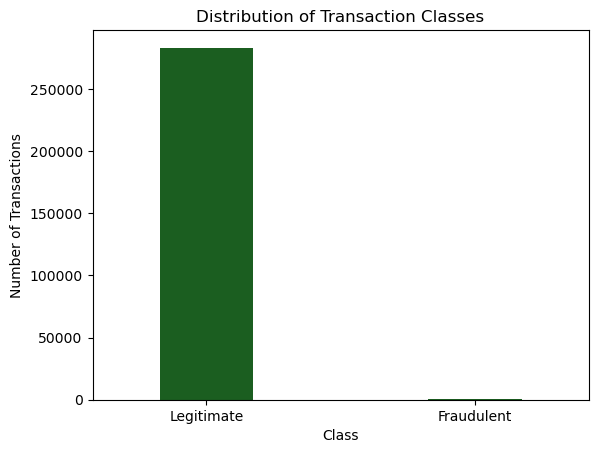

In [17]:
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(
    kind="bar",
    width=0.35,
    color="#1B5E20")

plt.title("Distribution of Transaction Classes")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"], rotation=0)
plt.show()

The normalized data shows again how unbalanced the dataset is, where 99.8273% of the transactions are legitimate and only 0.1727% of theme are fraudulent. This is why accuracy will not a meaningful measure of performance, as a baseline model that classifies all transactions as legitimate would attain a 99.8273% success rate.

In [23]:
df["Hour"] = (df["Time"] // 3600) % 24

Variables present considerably different ranges --> feature scaling
Standarisation will be accomplished since the model will rely on the reconstruction error

In [30]:
df.groupby("Hour")["Class"].mean() * 100

Hour
0.0     0.078462
1.0     0.237643
2.0     1.451028
3.0     0.487525
4.0     1.043557
5.0     0.368139
6.0     0.220480
7.0     0.317987
8.0     0.087959
9.0     0.101478
10.0    0.048344
11.0    0.315833
12.0    0.110548
13.0    0.110944
14.0    0.139225
15.0    0.158788
16.0    0.134179
17.0    0.173590
18.0    0.165104
19.0    0.122061
20.0    0.107752
21.0    0.090760
22.0    0.058525
23.0    0.156207
Name: Class, dtype: float64

Transforming variable "Time" to an hourly variable becomes interesting. Some hour periods show higher fraud rates, especially the 2-4am period. Nonetheless, we are working with too little fraudulent transactions to consider this as concluding.

In [33]:
df.groupby("Class")["Amount"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
Class,,,,,
0,88.413575,22.00,250.379023,0.0,25691.16
1,123.871860,9.82,260.211041,0.0,2125.87


Transaction amounts also show some interesting differences between the two classes. Fraudulent transactions have a higher mean but their median is lower. This suggests that fraudulent amounts are not characterized by higher transaction amounts. 

In [36]:
df["Amount"] = np.log1p(df["Amount"])       #Some transactions have an amount of 0

Time variable is transformed to be cyclical. This mantains the cyclical nature of time across different days.

In [39]:
df["Hour"] = (df["Time"] // 3600) % 24

df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

In [41]:
X = df.drop(columns=["Class"])
y = df["Class"]

X = X.drop(columns=["Time", "Hour"])

Legitimate and fraudulent transactions are separated. X_normal is used for training, while X_fraud is kept for evaluation.(X_fraud will not be used in the training part as we have chosen a non-supervised detection of anomalies).


In [44]:
X_normal = X[y == 0]
X_fraud = X[y == 1]

Only legitimate transactions are split into training, validation and testing sets.
Firstly, X_train -> 70% and X_temp -> 30%
Afterwards 50% is applied to X_temp, leaving the total as X_train -> 70%, X_val -> 15% and X_test -> 15%.

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_temp = train_test_split(
    X_normal,
    test_size=0.30,
    random_state=42
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.50,
    random_state=42
)

Data must be standarized, as extremely different numerical scales could affect the reconstruction error. This will be done using :

$$
z = \frac{x-\mu}{\sigma}
$$



In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_fraud_scaled = scaler.transform(X_fraud)

In [51]:
pd.DataFrame(X_train_scaled).describe().loc[["mean", "std"]]

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
mean,6.325030e-18,6.831211e-18,2.153735e-17,7.991397e-18,-5.464969e-18,-1.447769e-17,1.333094e-17,-3.449202e-18,2.342770e-17,5.178282e-18,...,-1.254255e-17,7.095501e-18,7.722628e-18,2.791614e-17,-1.225587e-17,2.508510e-18,-3.413366e-18,-2.793047e-16,6.740726e-17,1.580362e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,...,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00


Each transaction is represented as a vector $x \in \mathbb{R}^d$. The autoencoder maps this vector to a lower-dimensional latent representation and then reconstructs it. The model is trained using reconstruction error. Transactions that differ from the normal patterns learned during training should produce larger reconstruction errors.

The architecture will reduce the original 31 input variables to a reduced latent representation to reconstruct them afterwards.

As a starting point, I will use:
$$
\mathbb{R}^{31}
\rightarrow
\mathbb{R}^{16}
\rightarrow
\mathbb{R}^{8}
\rightarrow
\mathbb{R}^{16}
\rightarrow
\mathbb{R}^{31}
$$

In [56]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

In [57]:
tf.random.set_seed(21)
np.random.seed(21)

In [58]:
input_dim = X_train_scaled.shape[1]

inputs = Input(shape=(input_dim,))

encoder = Dense(16, activation="relu",kernel_regularizer=l2(1e-4))(inputs)
encoder = Dropout(0.1)(encoder)
encoder = Dense(8, activation="relu",kernel_regularizer=l2(1e-4))(encoder)

decoder = Dense(16, activation="relu",kernel_regularizer=l2(1e-4))(encoder)
decoder = Dropout(0.1)(decoder)
outputs = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs, outputs)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 31)             │           527 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319 (5.15 KB)

 Trainable params: 1,319 (5.15 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

Mean Squared Error (MSE)
$$
MSE(x,\hat{x}) =
\frac{1}{d}\sum_{j=1}^{d}(x_j-\hat{x}_j)^2
$$

to measure the difference between the original transaction and the reconstructed one.

Squaring the reconstruction errors makes the contribution of large deviations grow non-linearly. Validation loss is also monitored during the training part. This way we can study how well the model generalizes to legitimate transactions that were not included in the training set.

To avoid the issue of overfitting,Early Stopping is used. This makes training more robust and less reliant on a fixed epoch count.

In [62]:
es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    validation_data=(X_val_scaled, X_val_scaled),
    epochs=100,
    batch_size=256,
    shuffle=True,
    callbacks=[es],
    verbose=1
)

Epoch 1/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8888 - val_loss: 0.7568
Epoch 2/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7549 - val_loss: 0.6843
Epoch 3/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7058 - val_loss: 0.6329
Epoch 4/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6739 - val_loss: 0.6048
Epoch 5/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6565 - val_loss: 0.5919
Epoch 6/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6468 - val_loss: 0.5831
Epoch 7/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6402 - val_loss: 0.5779
Epoch 8/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6349 - val_loss: 0.5719
Epoch 9/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6267 - val_loss: 0.5640
Epoch 10/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6193 - val_loss: 0.5563
Epoch 11/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6135 - val_loss: 0.5494
Epoch 12/100
775/775 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
######

In [ ]:
# IN PROGRESS

In [ ]:
######